In [2]:
import cv2
import skfuzzy as fuzz
import numpy as np

from os import getcwd
from os.path import join,dirname,abspath
from skfuzzy import control as ctrl


In [3]:
import numpy as np
from IPython.display import display, Image
import io
from PIL import Image as PILImage
import matplotlib.pyplot as plt

def show_image_np(image_array):
    # Convertir la matriz NumPy a un objeto PIL
    pil_image = PILImage.fromarray(image_array)

    # Convertir la imagen PIL a un objeto BytesIO
    buffer = io.BytesIO()
    pil_image.save(buffer, format='PNG')
    buffer.seek(0)

    # Mostrar la imagen en el notebook
    display(Image(data=buffer.read(), format='PNG'))

def show_model(antecedent,a_universe,consequent,c_universe):
    # Graficar las funciones de membresía
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

    # Funciones de membresía para C (low y high)
    ax[0].plot(a_universe, antecedent["low"].mf, 'b', linewidth=1.5, label='Low')
    ax[0].plot(a_universe, antecedent["medium"].mf, 'g', linewidth=1.5, label='Medium')
    ax[0].plot(a_universe, antecedent["high"].mf, 'r', linewidth=1.5, label='High')
    ax[0].set_title('Funciones de Membresía para C')
    ax[0].legend()

    # Funciones de membresía para edge (no y yes)
    ax[1].plot(c_universe, consequent["low"].mf, 'b', linewidth=1.5, label='No')
    ax[1].plot(c_universe, consequent["yes"].mf, 'r', linewidth=1.5, label='Yes')
    ax[1].plot(c_universe, consequent["high"].mf, 'y', linewidth=1.5, label='high')   
    ax[1].set_title('Funciones de Membresía para Edge')
    ax[1].legend()

    plt.tight_layout()
    plt.show()

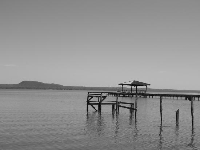

In [14]:
filename = join(dirname(getcwd()), "img/lago-ypacarai (5).jpg")

image=cv2.imread(filename)

x,y,a = image.shape
#image2=filter_h(image)
imagen=cv2.resize(image, (200, int(x*200/y)))
gray=cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
show_image_np(gray)

min_pixel = gray.min()
max_pixel = gray.max()

universe = np.arange(min_pixel, max_pixel, (1/256))
antecedent = ctrl.Antecedent(universe,f'C1')


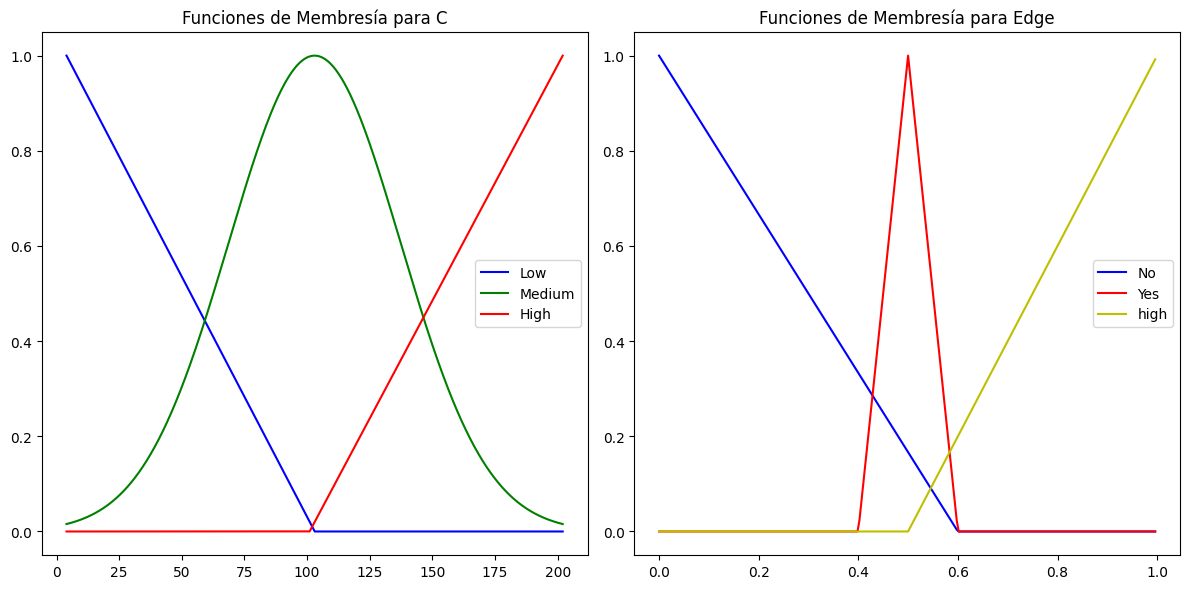

In [19]:
valor_medio = int((int(min_pixel)+int(max_pixel))/2)

antecedent['low'] = fuzz.trimf(universe, [min_pixel, min_pixel, valor_medio])
antecedent['medium'] = fuzz.gaussmf(universe,valor_medio,valor_medio/3)
antecedent['high'] = fuzz.trimf(universe, [max_pixel/2, max_pixel, max_pixel])

consequent_universe = np.arange(0, 256)/256

consequent = ctrl.Consequent(consequent_universe, 'edge')

consequent['low'] = fuzz.trimf(consequent_universe, [0, 0, 0.6])
consequent['high']= fuzz.trimf(consequent_universe, [0.5, 1, 1])
consequent['yes'] = fuzz.trimf(consequent_universe, [0.4, 0.5, 0.6])

show_model(antecedent,universe,consequent,consequent_universe)

In [24]:
type(min_pixel)

numpy.uint8